Name: Adwaith Krishna M H 

Class: R3AI

Roll No: B25CTA12

DATE: 10-08-2026

QUESTIONS

LOGISITIC REGRESSION 

You are provided with pima indians diabetes dataset (diabetes.csv) which contains diagnostic measurements for female patients of pima indian heritage. perform the following tasks to develop and evaluate a logistic regression model for predicting diabetes:

1. load the diabetes dataset. define your feature set X to include all available variables (pregnancies, glucose, bloodpressure,skinthickness,insulin,BMI, diabetespedigreefunction, Age) and you target variable Y as Outcome. 

2. split the dataset into a training set (75%) and a test set (25%) using random_state=16 to ensure reproducability

3. insentiate a logisitc regression model (use random_state=16 and max_iter-1000). train it on the training set and use it to generate predictions (y_pred) for the test set.

4. generate a confusion matrix from y_test and y_pred. plot this confusion matrix as a heatmap using matplotlib

5. use the appropriate sklearn.metrics functions (eg accuracy_score, precision_score) to verify the metrics you calculated manually from the matrix

6. A new patient has the following measurements: [2,120,70,25,80,30.5,0.5,32]. using the obtained model, predict if the patient is diabetic or not

ANSWERS

1.1 LOAD DATATSET

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv(r"C:\Users\adwai\Downloads\diabetes.csv")

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


1.2 DEFINE X AND Y 

In [12]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
Y = df['Outcome']
print(X.head())
print(Y.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


2. SPLIT DATASET INTO TRAINING SET AND TEST SET

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=16
)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (576, 8)
Test set: (192, 8)


3. INSENTIATE LOGIC REGRESSION MODEL

In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=16, max_iter=1000)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

4. GENERATE CONFUSION MATRIX AND PLOT IT USING HEATMAP 

[[116   9]
 [ 25  42]]


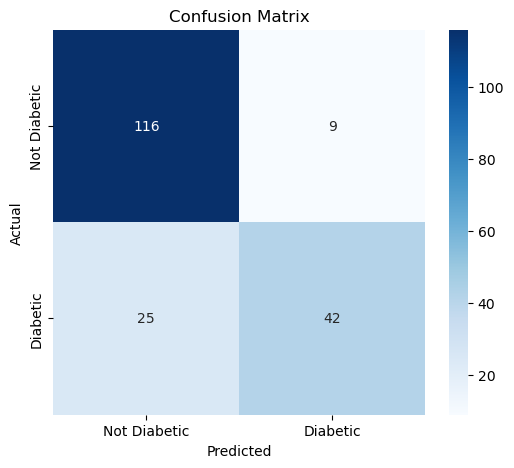

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(Y_test, y_pred)
print(cm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Diabetic', 'Diabetic'],
            yticklabels=['Not Diabetic', 'Diabetic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

5. USE SKLEARN METRIC FUNCTIONS TO VERIFY METRICS CALCULATED MANUALLY

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
f1= f1_score(Y_test, y_pred)
recall= recall_score (Y_test, y_pred)
print("ACCURACY MODEL GAVE:", accuracy)
print("PRECISION MODEL GAVE:", precision)
print("RECALL MODEL GAVCE", recall)
print("F1 SCORE MODEL GAVE", f1)

ACCURACY MODEL GAVE: 0.8229166666666666
PRECISION MODEL GAVE: 0.8235294117647058
RECALL MODEL GAVCE 0.6268656716417911
F1 SCORE MODEL GAVE 0.711864406779661


6. New Patient [2,120,70,25,80,30.5,0.5,32]. using model, predict if the patient is diabetic or not

In [31]:
new_patient = pd.DataFrame(
    [[2, 120, 70, 25, 80, 30.5, 0.5, 32]],
    columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])
prediction = model.predict(new_patient)
if prediction[0] == 1:
    print("The patient is diabetic.")
else:
    print("The patient is not diabetic.")

The patient is not diabetic.
